# Signal regression: predicting metabolite-NAFLD associations from the correlation graph

Leave-one-study-out. The other studies' pooled Kendall taus are propagated across the
metabolite correlation graph, and scored against the held-out study's true taus, split
into two prediction regimes:

- **tear A** -- measured in the held-out study, in *none* of the others. No direct seed
  exists anywhere, so the prediction is pure extrapolation from graph + chemistry.
- **tear B** -- measured in the held-out study *and* in at least one other. A seed
  already anchors the node; the task is refinement.

All data loading, fold construction and scoring live in `src/mwnetwork/loso.py`; the
models live in `src/mwnetwork/propagation.py`. This notebook is just the experiments.

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from src.mwnetwork.loso import LosoDataset, score_tears, tear_masks, TEAR_A, TEAR_B
from src.mwnetwork.propagation import (
    fit_covariate_baseline,
    propagate,
    permute_W,
    random_W_like,
)

data = LosoDataset()
data

/anaconda3/envs/metaboenv/lib/python3.14/site-packages/sspa/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


LosoDataset(9 studies, 4429 nodes, 793065 edges, 20 features)

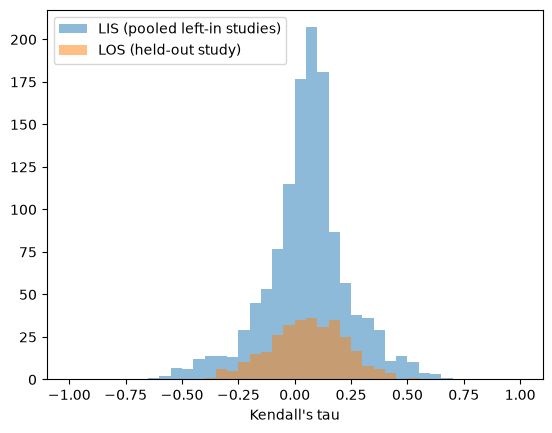

,A_untested_in_LIS,B_tested_in_LIS
ST000916,105,152
ST000977,39,22
ST001710,16,119
ST001711,0,31
ST001842,95,45
ST001843,79,189
ST001964,5,10
ST002091,607,72
ST002269,123,186


In [2]:
# what a fold looks like: pooled training signal vs the held-out truth
fold = data.fold("ST002269")
plt.hist(fold["lis_tau"], bins=np.linspace(-1, 1, 41), alpha=0.5, label="LIS (pooled left-in studies)")
plt.hist(fold["los_tau"], bins=np.linspace(-1, 1, 41), alpha=0.5, label="LOS (held-out study)")
plt.xlabel("Kendall's tau")
plt.legend()
plt.show()

# how many metabolites each fold is scored on, per tear
tear_sizes = pd.DataFrame(
    {study_id: {tear: int(mask.sum()) for tear, mask in tear_masks(data.fold(study_id)).items()}
     for study_id in data.study_ids}
).T
tear_sizes

## Experiment 1: propagation, with and without covariate adjustment

Three models, scored on the same folds and the same alpha grid:

- `raw_seed` -- propagate the pooled tau directly.
- `covariate_only` -- predict from node chemistry alone (super class one-hot + exact
  mass), precision-weighted least squares, no graph at all. Alpha-independent.
- `covariate_adjusted` -- regress the chemistry out first, propagate the residual, add
  the baseline back.

`alpha` is the smoothing strength: at 0 the graph term vanishes entirely, and the larger
it gets the more the topology dictates the answer.

In [3]:
ALPHAS = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0]

rows = []
for study_id in data.study_ids:
    fold = data.fold(study_id)
    S = fold["lis_precision"].fillna(0.0).to_numpy()
    y_seed = fold["lis_tau"].fillna(0.0).to_numpy()
    _, y_baseline, residual = fit_covariate_baseline(fold["X"].to_numpy(), y_seed, S)

    for alpha in ALPHAS:
        f_raw, conv_raw = propagate(data.W, S, y_seed, alpha=alpha)
        f_cov, conv_cov = propagate(data.W, S, residual, alpha=alpha)
        shared = dict(study_id=study_id, alpha=alpha)
        rows += score_tears(f_raw, fold, model="raw_seed", converged=conv_raw, **shared)
        rows += score_tears(y_baseline + f_cov, fold, model="covariate_adjusted", converged=conv_cov, **shared)
        rows += score_tears(y_baseline, fold, model="covariate_only", converged=True, **shared)

results = pd.DataFrame(rows)
results

,model,converged,study_id,alpha,tear,n,spearman_r,spearman_p
0,raw_seed,True,ST000916,0.0,A_untested_in_LIS,105,NaN,NaN
1,raw_seed,True,ST000916,0.0,B_tested_in_LIS,152,0.271878,7.031986e-04
2,covariate_adjusted,True,ST000916,0.0,A_untested_in_LIS,105,0.305496,1.529357e-03
3,covariate_adjusted,True,ST000916,0.0,B_tested_in_LIS,152,0.271878,7.031986e-04
4,covariate_only,True,ST000916,0.0,A_untested_in_LIS,105,0.305496,1.529357e-03
...,...,...,...,...,...,...,...,...
535,raw_seed,True,ST002269,10.0,B_tested_in_LIS,186,0.467404,1.747602e-11
536,covariate_adjusted,True,ST002269,10.0,A_untested_in_LIS,123,0.208433,2.069523e-02
537,covariate_adjusted,True,ST002269,10.0,B_tested_in_LIS,186,0.407466,7.829271e-09
538,covariate_only,True,ST002269,10.0,A_untested_in_LIS,123,0.099141,2.752763e-01


In [4]:
# CG is not guaranteed to converge: a wide dynamic range in S makes the system
# ill-conditioned at small alpha. Check where it ran out of iterations.
results[~results["converged"]].groupby(["model", "alpha"])["study_id"].nunique()

model               alpha
covariate_adjusted  0.10     9
                    0.25     9
                    0.50     9
                    1.00     9
                    2.00     9
                    3.00     9
                    5.00     7
raw_seed            0.10     9
                    0.25     9
                    0.50     9
                    1.00     9
                    2.00     9
                    3.00     9
                    5.00     7
Name: study_id, dtype: int64

In [5]:
# mean rho across studies, per model and alpha
agg = (
    results.groupby(["model", "tear", "alpha"])["spearman_r"]
    .agg(mean="mean", std="std", count="count").reset_index()
)
agg["sem"] = agg["std"] / np.sqrt(agg["count"])
agg.pivot_table(index=["tear", "alpha"], columns="model", values="mean")

model                    covariate_adjusted  covariate_only  raw_seed
tear              alpha                                              
A_untested_in_LIS 0.00             0.179117        0.179117       NaN
                  0.10             0.246590        0.179117  0.274662
                  0.25             0.248365        0.179117  0.273932
                  0.50             0.247805        0.179117  0.275814
                  1.00             0.208747        0.179117  0.273688
                  2.00             0.206785        0.179117  0.271323
                  3.00             0.215212        0.179117  0.271365
                  5.00             0.208669        0.179117  0.273805
                  7.00             0.202745        0.179117  0.272509
                  10.00            0.202081        0.179117  0.274223
B_tested_in_LIS   0.00             0.234045        0.121977  0.234045
                  0.10             0.238118        0.121977  0.236770
                  0.25             0.246672        0.121977  0.245529
                  0.50             0.253978        0.121977  0.250268
                  1.00             0.261818        0.121977  0.260033
                  2.00             0.271479        0.121977  0.270152
                  3.00             0.277949        0.121977  0.272948
                  5.00             0.278430        0.121977  0.279642
                  7.00             0.274055        0.121977  0.287083
                  10.00            0.275434        0.121977  0.314577

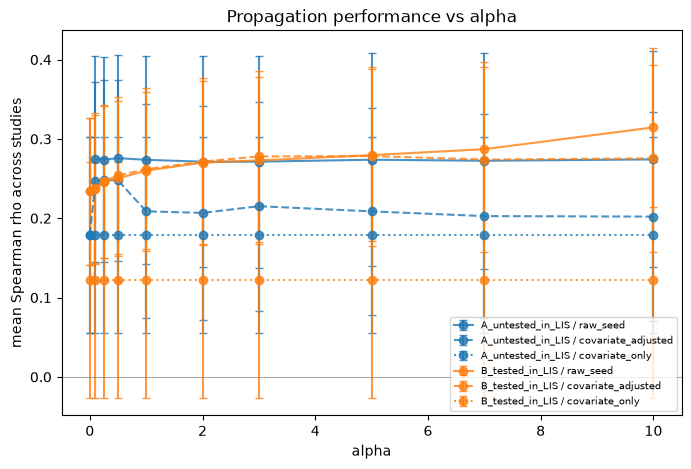

In [6]:
# aggregate view: does covariate adjustment help, and does alpha matter?
model_styles = {"raw_seed": "-", "covariate_adjusted": "--", "covariate_only": ":"}
tear_colors = {TEAR_A: "tab:blue", TEAR_B: "tab:orange"}

plt.figure(figsize=(8, 5))
for tear, color in tear_colors.items():
    for model, ls in model_styles.items():
        sub = agg[(agg.tear == tear) & (agg.model == model)]
        plt.errorbar(sub["alpha"], sub["mean"], yerr=sub["sem"], marker="o", ls=ls,
                     color=color, capsize=3, alpha=0.8, label=f"{tear} / {model}")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("alpha")
plt.ylabel("mean Spearman rho across studies")
plt.title("Propagation performance vs alpha")
plt.legend(fontsize=7)
plt.show()

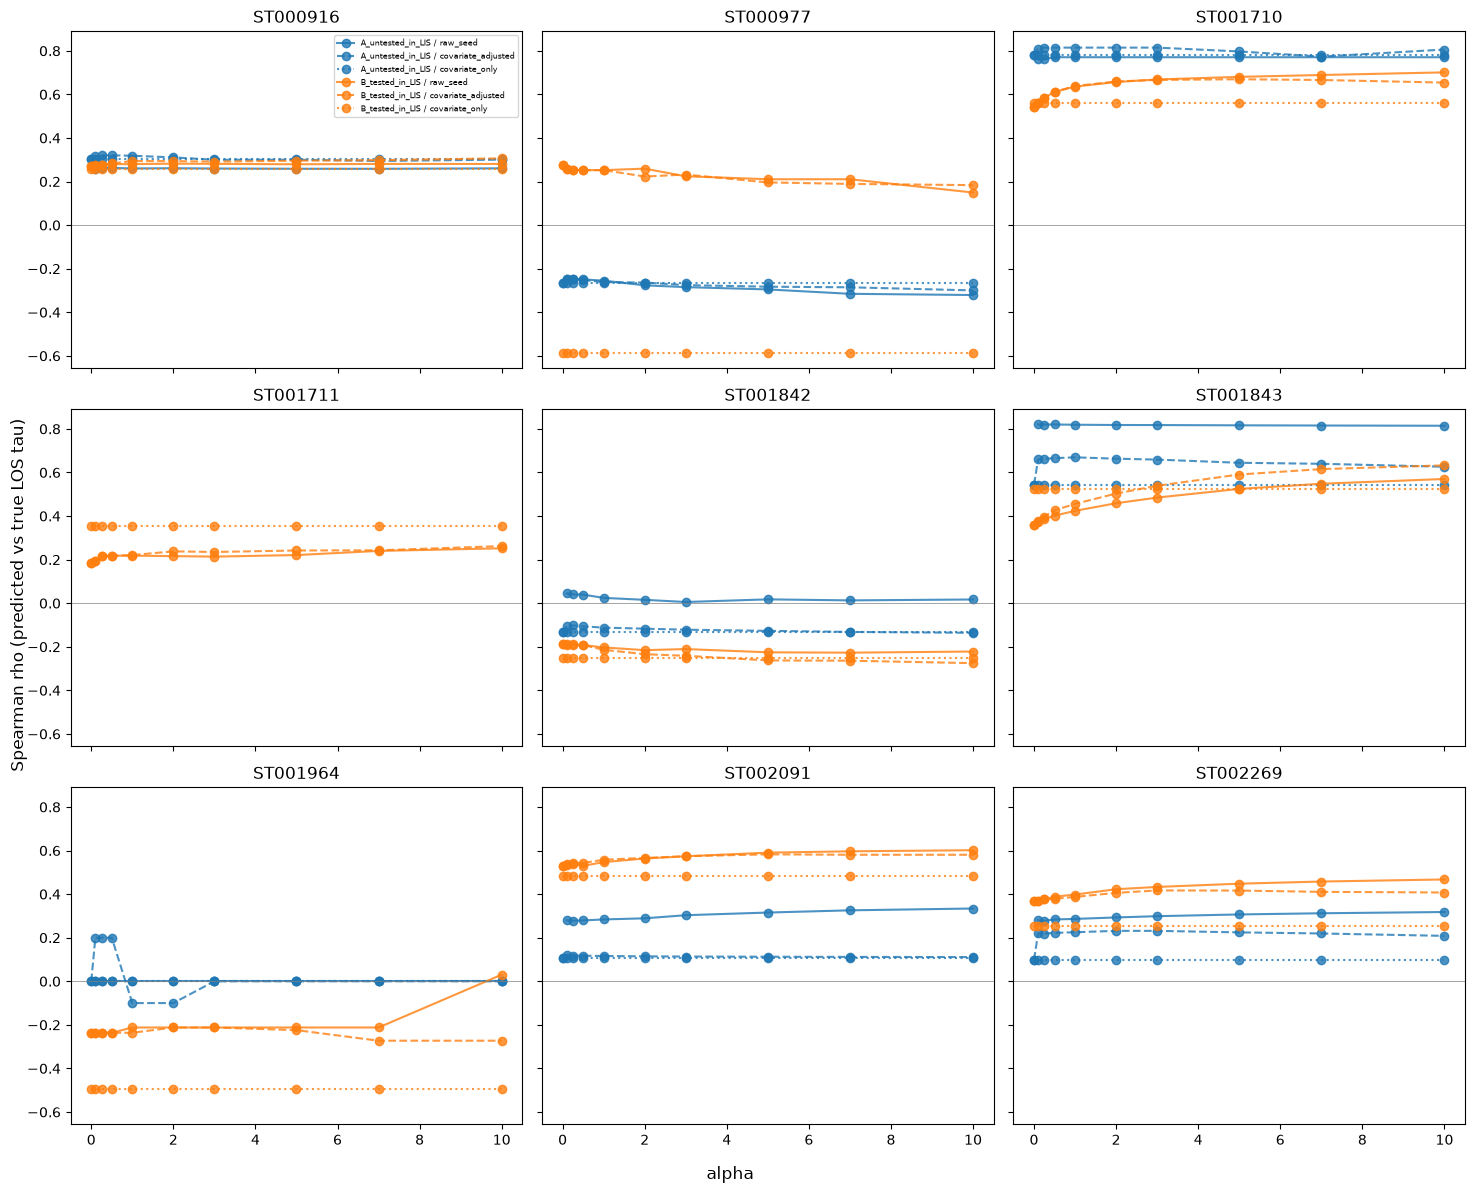

In [7]:
# per-study curves -- the aggregate hides a lot of fold-to-fold variation
ncols = 3
nrows = int(np.ceil(len(data.study_ids) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True)

for ax, study_id in zip(axes.ravel(), data.study_ids):
    sub_study = results[results.study_id == study_id]
    for tear, color in tear_colors.items():
        for model, ls in model_styles.items():
            sub = sub_study[(sub_study.tear == tear) & (sub_study.model == model)]
            ax.plot(sub["alpha"], sub["spearman_r"], marker="o", ls=ls, color=color,
                    alpha=0.8, label=f"{tear} / {model}")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(study_id)

for ax in axes.ravel()[len(data.study_ids):]:
    ax.axis("off")

axes.ravel()[0].legend(fontsize=6)
fig.supxlabel("alpha")
fig.supylabel("Spearman rho (predicted vs true LOS tau)")
plt.tight_layout()
plt.show()

In [8]:
# head-to-head: covariate-adjusted minus raw, paired by fold
wide = results.pivot_table(index=["study_id", "alpha", "tear"], columns="model", values="spearman_r")
wide["delta"] = wide["covariate_adjusted"] - wide["raw_seed"]

wide.groupby(["tear", "alpha"])["delta"].agg(
    mean_delta="mean",
    sem_delta=lambda s: s.std() / np.sqrt(s.notna().sum()),
    n_folds_improved=lambda s: int((s > 0).sum()),
    n_folds="count",
)

mean_delta  sem_delta  n_folds_improved  n_folds
tear              alpha                                                  
A_untested_in_LIS 0.00          NaN        NaN                 0        0
                  0.10    -0.028072   0.045632                 4        8
                  0.25    -0.025567   0.045333                 4        8
                  0.50    -0.028009   0.045141                 3        8
                  1.00    -0.064941   0.031224                 2        8
                  2.00    -0.064538   0.031882                 3        8
                  3.00    -0.056153   0.032796                 3        8
                  5.00    -0.065136   0.034584                 3        8
                  7.00    -0.069764   0.035202                 3        8
                  10.00   -0.072142   0.038293                 3        8
B_tested_in_LIS   0.00     0.000000   0.000000                 0        9
                  0.10     0.001348   0.001028                 4        9
                  0.25     0.001142   0.001346                 4        9
                  0.50     0.003711   0.003261                 5        9
                  1.00     0.001785   0.005441                 5        9
                  2.00     0.001327   0.007909                 5        9
                  3.00     0.005000   0.007962                 5        9
                  5.00    -0.001212   0.010526                 3        9
                  7.00    -0.013029   0.012813                 3        9
                  10.00   -0.039143   0.035924                 4        9

## Experiment 2: is it *this* graph, or just any graph?

The propagation numbers above only mean something if the specific topology of the
metabolite graph is doing the work. Two null graphs, run through the identical
raw-seed pipeline:

- **`permuted`** -- relabel the nodes (`P W P^T`). Topology preserved perfectly (same
  degrees, weights, spectrum, communities); only the graph-position-to-metabolite
  correspondence is destroyed. The strict null.
- **`erdos_renyi`** -- same node count, edge count and weight multiset, no structure.

Several seeds each, so we get a null distribution rather than a single draw.

In [9]:
ALPHAS_NULL = [0.0, 0.1, 0.5, 1.0, 3.0, 10.0]
N_SEEDS = 5

graphs = [("real", 0, data.W)]
for seed in range(N_SEEDS):
    rng = np.random.default_rng(seed)
    graphs.append(("permuted", seed, permute_W(data.W, rng)))
    graphs.append(("erdos_renyi", seed, random_W_like(data.W, rng)))

# the nulls must differ from the real graph ONLY in the ways intended
for label, seed, W_null in graphs[:3]:
    degree = np.asarray(W_null.sum(axis=1)).ravel()
    print(f"{label:12s} nnz={W_null.nnz}  weight_sum={W_null.sum():.3f}  "
          f"degree mean={degree.mean():.2f} std={degree.std():.2f}")

real         nnz=1586130  weight_sum=194762.235  degree mean=43.97 std=44.80
permuted     nnz=1586130  weight_sum=194762.235  degree mean=43.97 std=44.80
erdos_renyi  nnz=1586130  weight_sum=194762.235  degree mean=43.97 std=3.48


In [10]:
null_rows = []
for graph_label, seed, W_null in graphs:
    for study_id in data.study_ids:
        fold = data.fold(study_id)
        S = fold["lis_precision"].fillna(0.0).to_numpy()
        y_seed = fold["lis_tau"].fillna(0.0).to_numpy()
        for alpha in ALPHAS_NULL:
            f, converged = propagate(W_null, S, y_seed, alpha=alpha)
            null_rows += score_tears(f, fold, graph=graph_label, seed=seed,
                                     study_id=study_id, alpha=alpha, converged=converged)

null_results = pd.DataFrame(null_rows)
null_agg = (
    null_results.groupby(["graph", "tear", "alpha"])["spearman_r"]
    .agg(mean="mean", std="std", count="count").reset_index()
)
null_agg["sem"] = null_agg["std"] / np.sqrt(null_agg["count"])
null_agg.pivot_table(index=["tear", "alpha"], columns="graph", values="mean")

graph                    erdos_renyi  permuted      real
tear              alpha                                 
A_untested_in_LIS 0.1       0.037373  0.101350  0.274662
                  0.5       0.035794  0.103049  0.275814
                  1.0       0.037298  0.100184  0.273688
                  3.0       0.042268  0.091790  0.271365
                  10.0      0.046637  0.075832  0.274223
B_tested_in_LIS   0.0       0.234045  0.234045  0.234045
                  0.1       0.234951  0.235024  0.236770
                  0.5       0.238159  0.240268  0.250268
                  1.0       0.242432  0.242156  0.260033
                  3.0       0.251311  0.244675  0.272948
                  10.0      0.256142  0.246931  0.314577

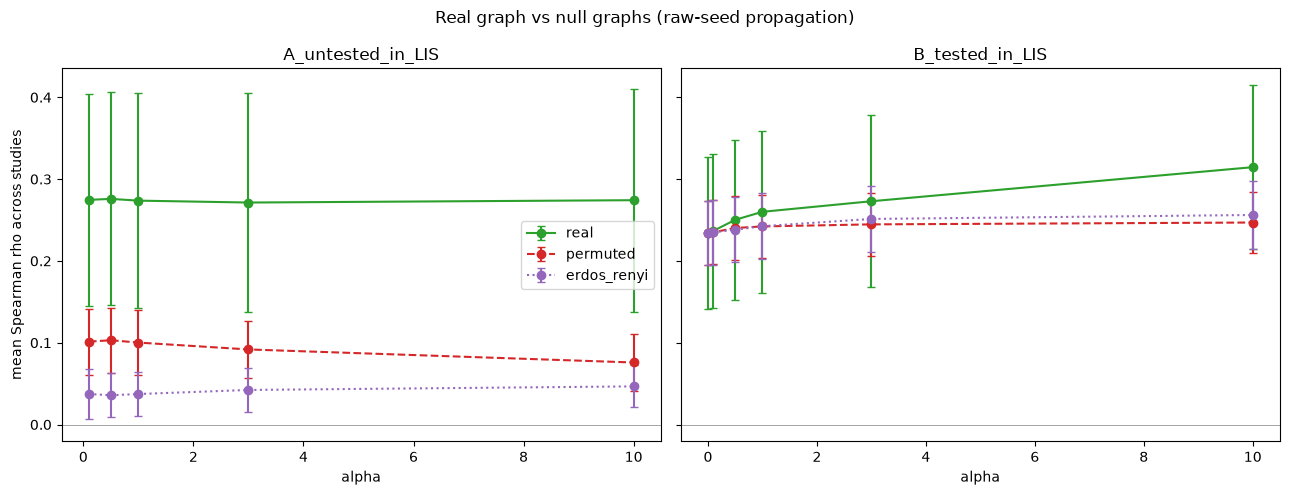

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
graph_styles = {"real": ("tab:green", "-"), "permuted": ("tab:red", "--"), "erdos_renyi": ("tab:purple", ":")}

for ax, tear in zip(axes, [TEAR_A, TEAR_B]):
    for graph_label, (color, ls) in graph_styles.items():
        sub = null_agg[(null_agg.graph == graph_label) & (null_agg.tear == tear)]
        ax.errorbar(sub["alpha"], sub["mean"], yerr=sub["sem"], marker="o", ls=ls,
                    color=color, capsize=3, label=graph_label)
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(tear)
    ax.set_xlabel("alpha")
axes[0].set_ylabel("mean Spearman rho across studies")
axes[0].legend()
fig.suptitle("Real graph vs null graphs (raw-seed propagation)")
plt.tight_layout()
plt.show()

In [12]:
# does any null draw ever match the real graph?
null_by_seed = (
    null_results[null_results.graph != "real"]
    .groupby(["graph", "seed", "alpha", "tear"])["spearman_r"].mean()
    .rename("null_rho").reset_index()
)
real_mean = (
    null_results[null_results.graph == "real"]
    .groupby(["alpha", "tear"])["spearman_r"].mean().rename("real_rho").reset_index()
)
null_vs_real = null_by_seed.merge(real_mean, on=["alpha", "tear"])

null_vs_real["null_beats_real"] = null_vs_real["null_rho"] >= null_vs_real["real_rho"]

null_vs_real.groupby(["tear", "alpha", "graph"]).agg(
    real_rho=("real_rho", "first"),
    null_rho_mean=("null_rho", "mean"),
    null_rho_max=("null_rho", "max"),
    n_seeds_beating_real=("null_beats_real", "sum"),
    n_seeds=("null_beats_real", "count"),
)

real_rho  null_rho_mean  null_rho_max  \
tear              alpha graph                                                
A_untested_in_LIS 0.0   erdos_renyi       NaN            NaN           NaN   
                        permuted          NaN            NaN           NaN   
                  0.1   erdos_renyi  0.274662       0.037373      0.121946   
                        permuted     0.274662       0.101350      0.186544   
                  0.5   erdos_renyi  0.275814       0.035794      0.105847   
                        permuted     0.275814       0.103049      0.181690   
                  1.0   erdos_renyi  0.273688       0.037298      0.103861   
                        permuted     0.273688       0.100184      0.177527   
                  3.0   erdos_renyi  0.271365       0.042268      0.086013   
                        permuted     0.271365       0.091790      0.138056   
                  10.0  erdos_renyi  0.274223       0.046637      0.090463   
                        permuted     0.274223       0.075832      0.144983   
B_tested_in_LIS   0.0   erdos_renyi  0.234045       0.234045      0.234045   
                        permuted     0.234045       0.234045      0.234045   
                  0.1   erdos_renyi  0.236770       0.234951      0.235209   
                        permuted     0.236770       0.235024      0.238075   
                  0.5   erdos_renyi  0.250268       0.238159      0.238894   
                        permuted     0.250268       0.240268      0.243742   
                  1.0   erdos_renyi  0.260033       0.242432      0.247779   
                        permuted     0.260033       0.242156      0.250629   
                  3.0   erdos_renyi  0.272948       0.251311      0.256110   
                        permuted     0.272948       0.244675      0.254100   
                  10.0  erdos_renyi  0.314577       0.256142      0.259454   
                        permuted     0.314577       0.246931      0.260159   

                                     n_seeds_beating_real  n_seeds  
tear              alpha graph                                       
A_untested_in_LIS 0.0   erdos_renyi                     0        5  
                        permuted                        0        5  
                  0.1   erdos_renyi                     0        5  
                        permuted                        0        5  
                  0.5   erdos_renyi                     0        5  
                        permuted                        0        5  
                  1.0   erdos_renyi                     0        5  
                        permuted                        0        5  
                  3.0   erdos_renyi                     0        5  
                        permuted                        0        5  
                  10.0  erdos_renyi                     0        5  
                        permuted                        0        5  
B_tested_in_LIS   0.0   erdos_renyi                     5        5  
                        permuted                        5        5  
                  0.1   erdos_renyi                     0        5  
                        permuted                        1        5  
                  0.5   erdos_renyi                     0        5  
                        permuted                        0        5  
                  1.0   erdos_renyi                     0        5  
                        permuted                        0        5  
                  3.0   erdos_renyi                     0        5  
                        permuted                        0        5  
                  10.0  erdos_renyi                     0        5  
                        permuted                        0        5

In [13]:
# the permuted null does not sit at exactly 0 on tear A -- is that a real effect,
# or just the folds with a handful of tear-A metabolites dominating an unweighted mean?
perm_A = (
    null_results[(null_results.graph == "permuted") & (null_results.tear == TEAR_A)]
    .groupby(["study_id", "alpha"])["spearman_r"].mean().unstack()
)
real_A = (
    null_results[(null_results.graph == "real") & (null_results.tear == TEAR_A)]
    .set_index(["study_id", "alpha"])["spearman_r"].unstack()
)

comparison_A = pd.concat(
    {"n_tear_A": tear_sizes[TEAR_A], "permuted_null": perm_A[1.0], "real": real_A[1.0]},
    axis=1,
)
comparison_A["real_minus_null"] = comparison_A["real"] - comparison_A["permuted_null"]
comparison_A.sort_values("n_tear_A", ascending=False).round(3)

,n_tear_A,permuted_null,real,real_minus_null
ST002091,607,0.038,0.284,0.246
ST002269,123,-0.019,0.286,0.306
ST000916,105,0.006,0.260,0.254
ST001842,95,0.000,0.024,0.024
ST001843,79,0.039,0.819,0.781
ST000977,39,0.109,-0.255,-0.364
ST001710,16,0.189,0.771,0.581
ST001964,5,0.440,0.000,-0.440
ST001711,0,NaN,NaN,NaN


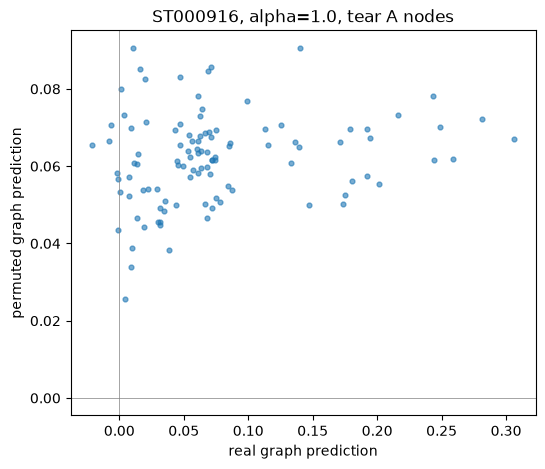

tear A prediction spread -- real: 0.07035   permuted: 0.01171


In [14]:
# node level: the real graph should spread predictions out, the null should not
study_id, alpha = data.study_ids[0], 1.0
fold = data.fold(study_id)
S = fold["lis_precision"].fillna(0.0).to_numpy()
y_seed = fold["lis_tau"].fillna(0.0).to_numpy()

pred_real = propagate(data.W, S, y_seed, alpha=alpha)[0]
pred_perm = propagate(permute_W(data.W, np.random.default_rng(0)), S, y_seed, alpha=alpha)[0]
mask_A = tear_masks(fold)[TEAR_A]

plt.figure(figsize=(6, 5))
plt.scatter(pred_real[mask_A], pred_perm[mask_A], s=12, alpha=0.6)
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("real graph prediction")
plt.ylabel("permuted graph prediction")
plt.title(f"{study_id}, alpha={alpha}, tear A nodes")
plt.show()

print("tear A prediction spread -- real: %.4g   permuted: %.4g"
      % (pred_real[mask_A].std(), pred_perm[mask_A].std()))

## Experiment 3: edge weighting, r vs r^2

Everything above uses `W = r**2` (shared variance). Squaring a correlation that is
already in [0, 1] penalises weak edges much harder than strong ones, so r^2 makes
propagation follow the few tight correlations while r lets weak ones contribute more
or less linearly. Whether that sharpening helps is an empirical question, so here is
the same experiment on `W = r`, scored the same way and against the same nulls.

In [15]:
from src.mwnetwork.loso import adjacency_matrix

W_by_weight = {"r2": data.W, "r": adjacency_matrix(data.G, power=1)}

for label, W_w in W_by_weight.items():
    degree = np.asarray(W_w.sum(axis=1)).ravel()
    print(f"{label:3s} nnz={W_w.nnz}  weight_sum={W_w.sum():.1f}  "
          f"edge weight min/median/max={W_w.data.min():.3f}/{np.median(W_w.data):.3f}/{W_w.data.max():.3f}  "
          f"degree mean={degree.mean():.2f} std={degree.std():.2f}")

r2  nnz=1586130  weight_sum=194762.2  edge weight min/median/max=0.001/0.067/1.000  degree mean=43.97 std=44.80
r   nnz=1586130  weight_sum=482057.2  edge weight min/median/max=0.026/0.258/1.000  degree mean=108.84 std=101.64


In [16]:
# same three models, same alpha grid, now for both weightings
rows_w = []
for weight_label, W_w in W_by_weight.items():
    for study_id in data.study_ids:
        fold = data.fold(study_id)
        S = fold["lis_precision"].fillna(0.0).to_numpy()
        y_seed = fold["lis_tau"].fillna(0.0).to_numpy()
        _, y_baseline, residual = fit_covariate_baseline(fold["X"].to_numpy(), y_seed, S)

        for alpha in ALPHAS:
            f_raw, conv_raw = propagate(W_w, S, y_seed, alpha=alpha)
            f_cov, conv_cov = propagate(W_w, S, residual, alpha=alpha)
            shared = dict(weight=weight_label, study_id=study_id, alpha=alpha)
            rows_w += score_tears(f_raw, fold, model="raw_seed", converged=conv_raw, **shared)
            rows_w += score_tears(y_baseline + f_cov, fold, model="covariate_adjusted", converged=conv_cov, **shared)

results_w = pd.DataFrame(rows_w)
results_w.groupby(["model", "tear", "alpha", "weight"])["spearman_r"].mean().unstack("weight")

weight                                             r        r2
model              tear              alpha                    
covariate_adjusted A_untested_in_LIS 0.00   0.179117  0.179117
                                     0.10   0.235266  0.246590
                                     0.25   0.197528  0.248365
                                     0.50   0.194826  0.247805
                                     1.00   0.201115  0.208747
                                     2.00   0.190496  0.206785
                                     3.00   0.185864  0.215212
                                     5.00   0.179792  0.208669
                                     7.00   0.175810  0.202745
                                     10.00  0.170801  0.202081
                   B_tested_in_LIS   0.00   0.234045  0.234045
                                     0.10   0.244237  0.238118
                                     0.25   0.255086  0.246672
                                     0.50   0.264942  0.253978
                                     1.00   0.271290  0.261818
                                     2.00   0.275319  0.271479
                                     3.00   0.273204  0.277949
                                     5.00   0.268698  0.278430
                                     7.00   0.284492  0.274055
                                     10.00  0.281486  0.275434
raw_seed           A_untested_in_LIS 0.00        NaN       NaN
                                     0.10   0.260866  0.274662
                                     0.25   0.259828  0.273932
                                     0.50   0.258538  0.275814
                                     1.00   0.260181  0.273688
                                     2.00   0.257043  0.271323
                                     3.00   0.255396  0.271365
                                     5.00   0.256952  0.273805
                                     7.00   0.256075  0.272509
                                     10.00  0.255956  0.274223
                   B_tested_in_LIS   0.00   0.234045  0.234045
                                     0.10   0.242707  0.236770
                                     0.25   0.249607  0.245529
                                     0.50   0.259816  0.250268
                                     1.00   0.267194  0.260033
                                     2.00   0.277013  0.270152
                                     3.00   0.280754  0.272948
                                     5.00   0.284313  0.279642
                                     7.00   0.308302  0.287083
                                     10.00  0.311187  0.314577

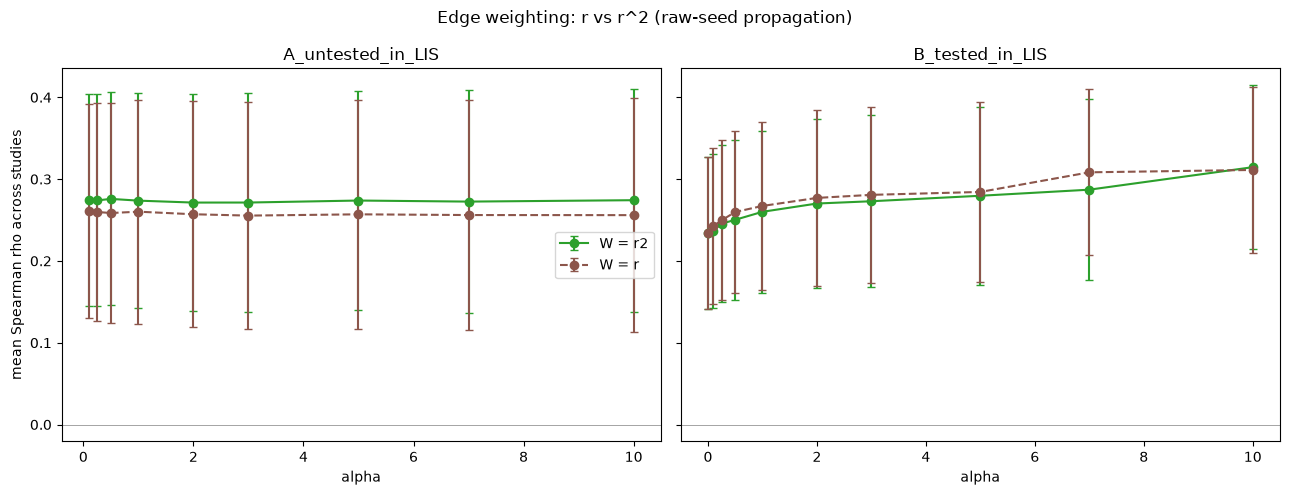

In [17]:
# r vs r^2, raw seed, per tear
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
weight_styles = {"r2": ("tab:green", "-"), "r": ("tab:brown", "--")}

for ax, tear in zip(axes, [TEAR_A, TEAR_B]):
    for weight_label, (color, ls) in weight_styles.items():
        sub = (results_w[(results_w.model == "raw_seed") & (results_w.tear == tear)
                         & (results_w.weight == weight_label)]
               .groupby("alpha")["spearman_r"].agg(["mean", "std", "count"]))
        ax.errorbar(sub.index, sub["mean"], yerr=sub["std"] / np.sqrt(sub["count"]),
                    marker="o", ls=ls, color=color, capsize=3, label=f"W = {weight_label}")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_title(tear)
    ax.set_xlabel("alpha")
axes[0].set_ylabel("mean Spearman rho across studies")
axes[0].legend()
fig.suptitle("Edge weighting: r vs r^2 (raw-seed propagation)")
plt.tight_layout()
plt.show()

In [18]:
# paired per fold: does r^2 beat r on the same study and alpha?
wide_w = results_w.pivot_table(index=["model", "study_id", "alpha", "tear"],
                               columns="weight", values="spearman_r")
wide_w["delta_r2_minus_r"] = wide_w["r2"] - wide_w["r"]

wide_w.groupby(["model", "tear", "alpha"])["delta_r2_minus_r"].agg(
    mean_delta="mean",
    sem_delta=lambda s: s.std() / np.sqrt(s.notna().sum()),
    n_folds_r2_better=lambda s: int((s > 0).sum()),
    n_folds="count",
)

mean_delta  sem_delta  \
model              tear              alpha                          
covariate_adjusted A_untested_in_LIS 0.00     0.000000   0.000000   
                                     0.10     0.011324   0.010949   
                                     0.25     0.050837   0.037661   
                                     0.50     0.052979   0.037221   
                                     1.00     0.007632   0.020193   
                                     2.00     0.016289   0.022432   
                                     3.00     0.029349   0.015389   
                                     5.00     0.028877   0.017490   
                                     7.00     0.026935   0.020509   
                                     10.00    0.031279   0.022878   
                   B_tested_in_LIS   0.00     0.000000   0.000000   
                                     0.10    -0.006120   0.003198   
                                     0.25    -0.008414   0.004179   
                                     0.50    -0.010964   0.006251   
                                     1.00    -0.009472   0.009596   
                                     2.00    -0.003840   0.011599   
                                     3.00     0.004745   0.013955   
                                     5.00     0.009732   0.012730   
                                     7.00    -0.010437   0.027487   
                                     10.00   -0.006052   0.029409   
raw_seed           A_untested_in_LIS 0.10     0.013796   0.011530   
                                     0.25     0.014105   0.013000   
                                     0.50     0.017277   0.013559   
                                     1.00     0.013507   0.014299   
                                     2.00     0.014280   0.012956   
                                     3.00     0.015969   0.012257   
                                     5.00     0.016852   0.011713   
                                     7.00     0.016434   0.011422   
                                     10.00    0.018267   0.013461   
                   B_tested_in_LIS   0.00     0.000000   0.000000   
                                     0.10    -0.005937   0.002756   
                                     0.25    -0.004078   0.003133   
                                     0.50    -0.009549   0.004900   
                                     1.00    -0.007161   0.006828   
                                     2.00    -0.006861   0.008343   
                                     3.00    -0.007806   0.011167   
                                     5.00    -0.004672   0.016367   
                                     7.00    -0.021218   0.030530   
                                     10.00    0.003390   0.007964   

                                            n_folds_r2_better  n_folds  
model              tear              alpha                              
covariate_adjusted A_untested_in_LIS 0.00                   0        8  
                                     0.10                   4        8  
                                     0.25                   5        8  
                                     0.50                   6        8  
                                     1.00                   5        8  
                                     2.00                   7        8  
                                     3.00                   7        8  
                                     5.00                   7        8  
                                     7.00                   5        8  
                                     10.00                  7        8  
                   B_tested_in_LIS   0.00                   0        9  
                                     0.10                   2        9  
                                     0.25                   2        9  
                                     0.50                   1        9  
                                     1.00     

In [19]:
# does the r-weighted graph still beat its own null?
null_rows_w = []
for weight_label, W_w in W_by_weight.items():
    graphs_w = [("real", 0, W_w)] + [
        ("permuted", seed, permute_W(W_w, np.random.default_rng(seed))) for seed in range(N_SEEDS)
    ]
    for graph_label, seed, W_null in graphs_w:
        for study_id in data.study_ids:
            fold = data.fold(study_id)
            S = fold["lis_precision"].fillna(0.0).to_numpy()
            y_seed = fold["lis_tau"].fillna(0.0).to_numpy()
            for alpha in ALPHAS_NULL:
                f, converged = propagate(W_null, S, y_seed, alpha=alpha)
                null_rows_w += score_tears(f, fold, weight=weight_label, graph=graph_label,
                                           seed=seed, study_id=study_id, alpha=alpha,
                                           converged=converged)

null_results_w = pd.DataFrame(null_rows_w)
null_results_w.groupby(["tear", "alpha", "weight", "graph"])["spearman_r"].mean().unstack(["weight", "graph"])

weight                          r                  r2          
graph                    permuted      real  permuted      real
tear              alpha                                        
A_untested_in_LIS 0.0         NaN       NaN       NaN       NaN
                  0.1    0.093441  0.260866  0.101305  0.274662
                  0.5    0.108800  0.258538  0.103041  0.275814
                  1.0    0.093129  0.260181  0.100184  0.273688
                  3.0    0.075112  0.255396  0.091790  0.271365
                  10.0   0.049816  0.255956  0.075832  0.274223
B_tested_in_LIS   0.0    0.234045  0.234045  0.234045  0.234045
                  0.1    0.236280  0.242707  0.235024  0.236770
                  0.5    0.245946  0.259816  0.240268  0.250268
                  1.0    0.246209  0.267194  0.242156  0.260033
                  3.0    0.248957  0.280754  0.244675  0.272948
                  10.0   0.255466  0.311187  0.246931  0.314577

In [20]:
# the gap that matters: real minus its own permuted null, per weighting
gap = (
    null_results_w.groupby(["tear", "alpha", "weight", "graph"])["spearman_r"].mean()
    .unstack("graph")
)
gap["real_minus_null"] = gap["real"] - gap["permuted"]
gap.round(3)

graph                           permuted   real  real_minus_null
tear              alpha weight                                  
A_untested_in_LIS 0.0   r            NaN    NaN              NaN
                        r2           NaN    NaN              NaN
                  0.1   r          0.093  0.261            0.167
                        r2         0.101  0.275            0.173
                  0.5   r          0.109  0.259            0.150
                        r2         0.103  0.276            0.173
                  1.0   r          0.093  0.260            0.167
                        r2         0.100  0.274            0.174
                  3.0   r          0.075  0.255            0.180
                        r2         0.092  0.271            0.180
                  10.0  r          0.050  0.256            0.206
                        r2         0.076  0.274            0.198
B_tested_in_LIS   0.0   r          0.234  0.234            0.000
                        r2         0.234  0.234            0.000
                  0.1   r          0.236  0.243            0.006
                        r2         0.235  0.237            0.002
                  0.5   r          0.246  0.260            0.014
                        r2         0.240  0.250            0.010
                  1.0   r          0.246  0.267            0.021
                        r2         0.242  0.260            0.018
                  3.0   r          0.249  0.281            0.032
                        r2         0.245  0.273            0.028
                  10.0  r          0.255  0.311            0.056
                        r2         0.247  0.315            0.068

In [21]:
# and on the well-powered folds only (tear A), where the null is actually estimable
well_powered = tear_sizes.index[tear_sizes[TEAR_A] >= 50]

per_fold_A = (
    null_results_w[(null_results_w.tear == TEAR_A) & (null_results_w.alpha == 1.0)
                   & (null_results_w.study_id.isin(well_powered))]
    .groupby(["study_id", "weight", "graph"])["spearman_r"].mean().unstack(["weight", "graph"])
)
per_fold_A.round(3)

weight          r              r2       
graph    permuted   real permuted   real
study_id                                
ST000916    0.020  0.249    0.006  0.260
ST001842   -0.007  0.005    0.000  0.024
ST001843    0.031  0.805    0.039  0.819
ST002091    0.037  0.296    0.038  0.284
ST002269   -0.023  0.330   -0.019  0.286